# Advanced Trader Strategy Signals

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.dpi"] = 140

In [20]:
df = pd.read_csv("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/csv_files/merged_trader_sentiment.csv")
df.head()


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,crossed,fee,trade_id,timestamp,time,date,classification,trade_volume,leverage,is_profitable
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,01-05-2023 01:06,0.1791,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,137.07892,7.653825e+02,False
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,01-05-2023 01:06,0.0000,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,183.52693,NaN,False
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,01-05-2023 01:06,0.0967,Open Long,0.0,...,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01 01:06:00,2023-05-01,greed,156.38696,1.617270e+03,False
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,05-12-2023 03:11,-0.0150,Open Short,0.0,...,True,6.092654,2.830000e+14,1.700000e+12,2023-12-05 03:11:00,2023-12-05,extreme greed,24370.61726,1.624708e+06,False
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41867.0,0.01500,628.00,SELL,05-12-2023 03:11,0.0000,Open Short,0.0,...,True,0.157001,1.070000e+15,1.700000e+12,2023-12-05 03:11:00,2023-12-05,extreme greed,628.00500,NaN,False


In [21]:
sharpe_proxy = (
    df.groupby("classification")["closed_pnl"]
      .agg(["mean", "std"])
      .reset_index()
)

sharpe_proxy["sharpe_proxy"] = sharpe_proxy["mean"] / sharpe_proxy["std"]
sharpe_proxy


,classification,mean,std,sharpe_proxy
0,extreme fear,34.537862,1136.056091,0.030402
1,extreme greed,67.892861,766.828294,0.088537
2,fear,54.290400,935.355438,0.058043
3,greed,43.582684,1120.064348,0.038911
4,neutral,34.307718,517.122220,0.066344


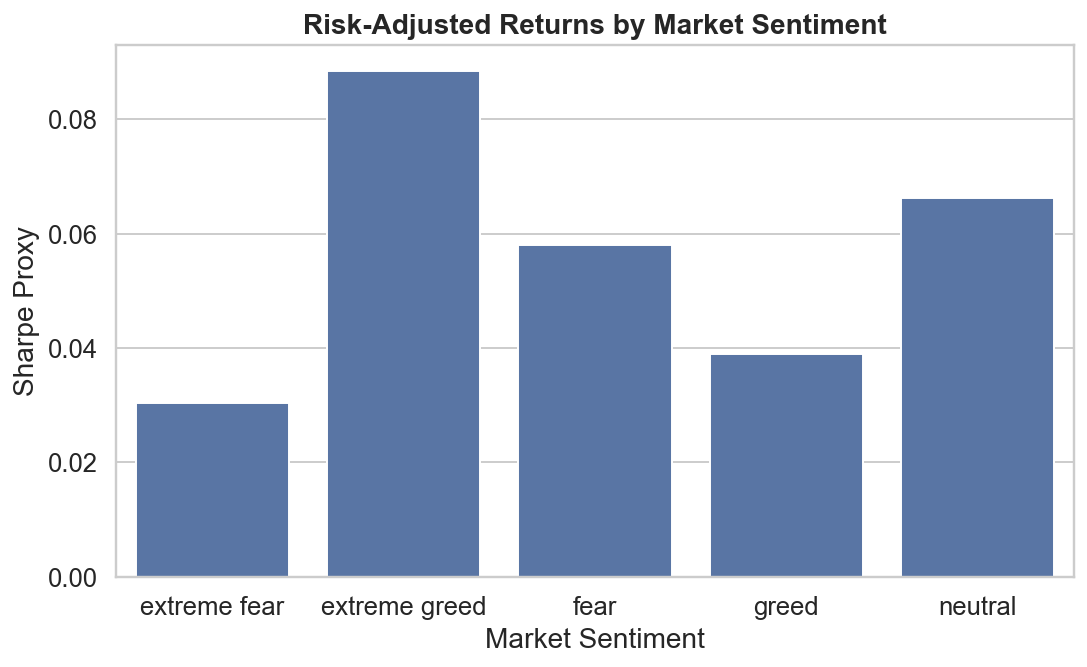

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=sharpe_proxy,
    x="classification",
    y="sharpe_proxy"
)

plt.title("Risk-Adjusted Returns by Market Sentiment", weight="bold")
plt.ylabel("Sharpe Proxy")
plt.xlabel("Market Sentiment")
plt.tight_layout()
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/sharpe_sentiment.png")
plt.show()


In [23]:
top_traders = (
    df.groupby("account")["closed_pnl"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

smart_money_df = df[df["account"].isin(top_traders)]


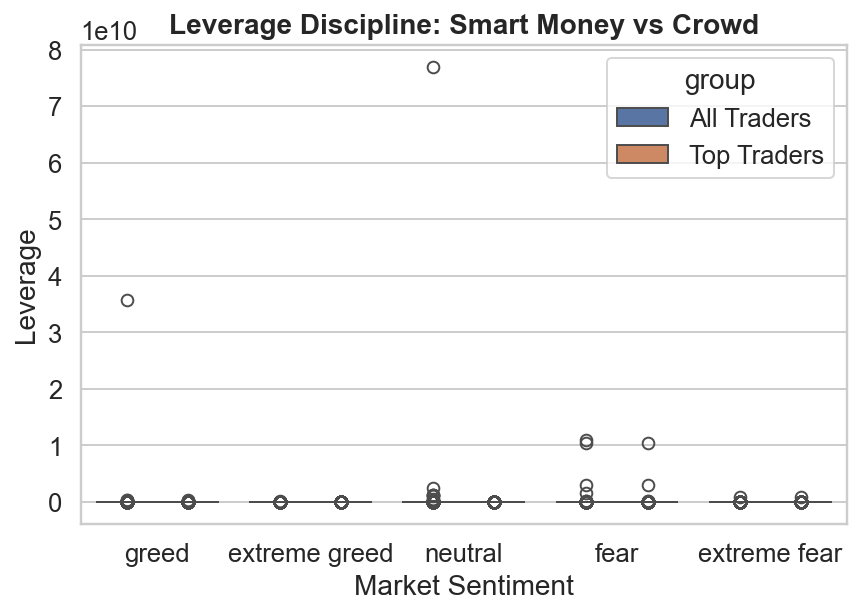

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

comparison = pd.concat(
    [
        df.assign(group="All Traders"),
        smart_money_df.assign(group="Top Traders")
    ],
    ignore_index=True
)

sns.boxplot(
    data=comparison.dropna(subset=["classification", "leverage"]),
    x="classification",
    y="leverage",
    hue="group"
)

plt.title("Leverage Discipline: Smart Money vs Crowd", weight="bold")
plt.xlabel("Market Sentiment")
plt.ylabel("Leverage")
plt.tight_layout()
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/smart_money_leverage.png")
plt.show()



In [25]:
df["leverage_risk_index"] = df["leverage"] * df["trade_volume"]

lri = df.groupby("classification")["leverage_risk_index"].mean()
lri


classification
extreme fear     2.441355e+08
extreme greed    2.768650e+08
fear             3.505624e+10
greed            2.954538e+09
neutral          4.913743e+09
Name: leverage_risk_index, dtype: float64

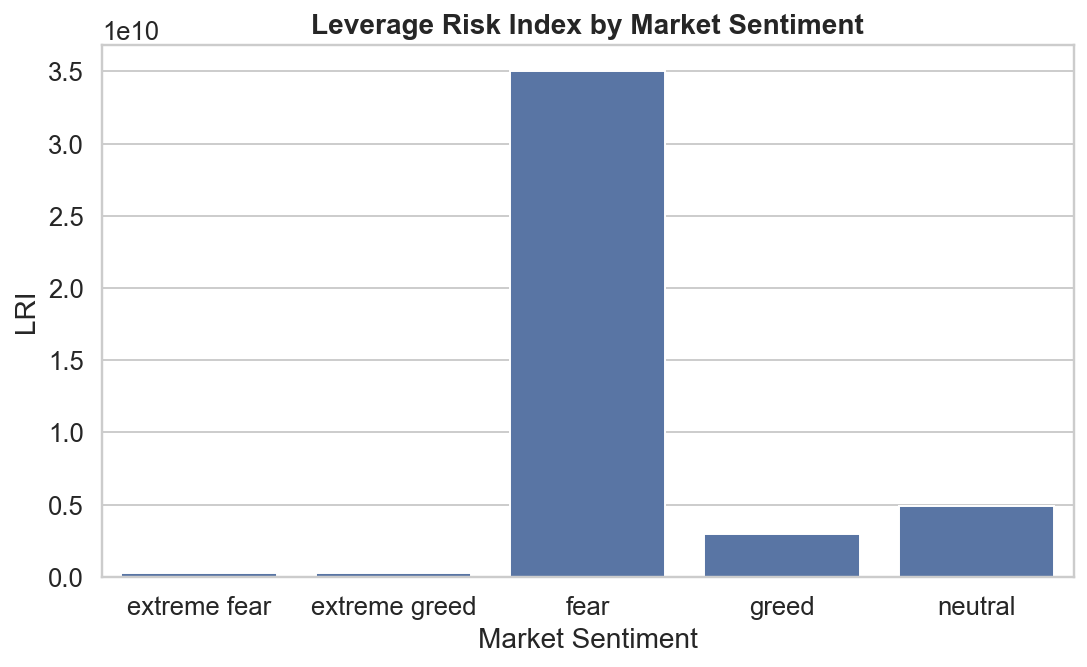

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=lri.index,
    y=lri.values
)

plt.title("Leverage Risk Index by Market Sentiment", weight="bold")
plt.ylabel("LRI")
plt.xlabel("Market Sentiment")
plt.tight_layout()
plt.savefig("C:/Users/Sanskar/Downloads/ds_sanskar_kocharekar_FINAL/outputs/lri_sentiment.png")
plt.show()


In [27]:
## 📈 Advanced Trading Signals

### 1️⃣ Sentiment-Aware Leverage Control
'''
- Reduce leverage during **Greed**
- Expand selectively during **Fear**

### 2️⃣ Smart Money Pattern
- Top traders trade **less**, but **better**
- Lower leverage + higher Sharpe

### 3️⃣ Risk Regime Detection
- High LRI = overheating market
- Use as a volatility filter

### ✅ Actionable Strategy
Combine sentiment + leverage caps + smart-money filtering
'''


'\n- Reduce leverage during **Greed**\n- Expand selectively during **Fear**\n\n### 2️⃣ Smart Money Pattern\n- Top traders trade **less**, but **better**\n- Lower leverage + higher Sharpe\n\n### 3️⃣ Risk Regime Detection\n- High LRI = overheating market\n- Use as a volatility filter\n\n### ✅ Actionable Strategy\nCombine sentiment + leverage caps + smart-money filtering\n'

In [28]:
print("✅ Advanced analysis completed.")
print("📊 Publication-quality plots saved in /outputs/")


✅ Advanced analysis completed.
📊 Publication-quality plots saved in /outputs/
